In [48]:
import numpy as np
import matplotlib.pyplot as plt

def read_inspect_b_data(filename):
    """
    Read data from inspect_b_output.dat file.
    
    Format:
    - Line 1: time (single number)
    - Following lines for each variable (psi, chi, b):
      - mode_index, radial_data1, radial_data2, ...
    - Pattern repeats for each time step
    
    Returns:
    - times: array of simulation times
    - data: list of dictionaries, each containing data for psi, chi, and b
    """
    times = []
    all_data = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    i = 0
    nrad = None  # Will be determined from first data line
    
    while i < len(lines):
        # Initialize data storage for this time step
        timestep_data = {
            'psi': {'mode_indices': [], 'data': []},
            'chi': {'mode_indices': [], 'data': []},
            'b': {'mode_indices': [], 'data': []},
            'nrad': nrad
        }
        
        # Read data for all three variables (psi, chi, b) - each has 2 lines: time + data
        variable_names = ['psi', 'chi', 'b']
        time_for_step = None
        
        for var_idx, var_name in enumerate(variable_names):
            # Check if we have enough lines remaining
            if i + 1 >= len(lines):
                break
                
            # Read time line (single number)
            time_line = lines[i].strip()
            try:
                time = float(time_line)
                if time_for_step is None:
                    time_for_step = time  # Store the time for this time step
                i += 1
            except ValueError:
                print(f"Warning: Could not parse time from line {i}: {time_line}")
                i += 1
                continue
            
            # Read data line (mode_index + radial_data)
            if i >= len(lines):
                break
                
            data_line = lines[i].strip()
            
            # Try to parse as data line (mode_index + radial_data)
            try:
                data_values = []
                for x in data_line.split():
                    try:
                        data_values.append(float(x.rstrip(',')))
                    except ValueError:
                        print(f"Warning: Could not convert '{x}' to float, setting to 0.0")
                        data_values.append(0.0)
                
                if len(data_values) < 2:
                    print(f"Warning: Insufficient data in line {i} for {var_name}")
                    i += 1
                    continue
                
                # Determine nrad from first successful data line
                if nrad is None:
                    nrad = len(data_values) - 1  # First number is mode index
                    timestep_data['nrad'] = nrad
                
                # Check if this has the expected number of data points
                if len(data_values) == nrad + 1:  # mode_index + nrad data points
                    mode_index = int(data_values[0])
                    radial_data = np.array(data_values[1:])
                    
                    timestep_data[var_name]['mode_indices'] = np.array([mode_index])
                    timestep_data[var_name]['data'] = np.array([radial_data])  # Shape: (1, n_radial)
                    i += 1
                else:
                    print(f"Warning: Unexpected data size in line {i} for {var_name}: expected {nrad+1}, got {len(data_values)}")
                    i += 1
                    
            except ValueError:
                print(f"Warning: Could not parse {var_name} data from line {i}: {data_line}")
                i += 1
                continue
        
        # Store the complete time step data if we got a valid time and at least some data
        if time_for_step is not None and any(len(timestep_data[var]['data']) > 0 for var in variable_names):
            times.append(time_for_step)
            timestep_data['nrad'] = nrad
            all_data.append(timestep_data)
    
    return np.array(times), all_data

def plot_data(times, all_data, variable='psi', mode_to_plot=1, radial_point=1, ax=None):
    """
    Plot time evolution of a specific radial point for a specific mode and variable.
    
    Parameters:
    - times: array of simulation times
    - all_data: list of data dictionaries
    - variable: variable to plot ('psi', 'chi', or 'b')
    - mode_to_plot: azimuthal mode index to plot
    - radial_point: radial grid point index to plot (1-based)
    - ax: optional matplotlib axes to plot on (if None, creates new figure)
    
    Returns:
    - ax: matplotlib axes object (if data was plotted)
    """
    if variable not in ['psi', 'chi', 'b']:
        print(f"Error: variable must be one of 'psi', 'chi', 'b', got '{variable}'")
        return None
        
    values = []
    valid_times = []
    
    for i, (time, data_dict) in enumerate(zip(times, all_data)):
        if variable not in data_dict or len(data_dict[variable]['data']) == 0:
            continue
            
        mode_indices = data_dict[variable]['mode_indices']
        data = data_dict[variable]['data']
        
        # Find the requested mode
        mode_mask = mode_indices == mode_to_plot
        if np.any(mode_mask):
            mode_data = data[mode_mask][0]  # Take first match
            if 0 <= radial_point-1 < len(mode_data):
                values.append(mode_data[radial_point-1])  # Convert to 0-based
                valid_times.append(time)
    
    if values:
        created_new_figure = False
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
            created_new_figure = True
        
        # Add label to distinguish different lines
        ax.plot(valid_times, values, linewidth=2, 
               label=f'{variable.upper()}: Mode {mode_to_plot}, Radial {radial_point}')
        ax.set_xlabel('Simulation Time')
        ax.set_ylabel('Value')
        ax.set_title(f'Time Evolution Comparison')
        ax.grid(True, alpha=0.3)
        ax.legend()  # Add legend to show different lines
        
        if created_new_figure:
            plt.show()
        
        return ax
    else:
        print(f"No data found for {variable} mode {mode_to_plot}")
        return None

def plot_spectrum(times, all_data, variable='psi', mode_to_plot=1, time_indices=None):
    """
    Plot the spectrum of a specific mode as a function of radial points.
    
    Parameters:
    - times: array of simulation times
    - all_data: list of data dictionaries
    - variable: variable to plot ('psi', 'chi', or 'b')
    - mode_to_plot: azimuthal mode index to plot
    - time_indices: optional list of time indices to plot (if None, plots all times)
    """
    if variable not in ['psi', 'chi', 'b']:
        print(f"Error: variable must be one of 'psi', 'chi', 'b', got '{variable}'")
        return
        
    if time_indices is None:
        time_indices = range(len(times))
    
    plt.figure(figsize=(14, 10))
    
    # Define colors for different time steps - use a colormap that can handle many colors
    if len(time_indices) <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))[:len(time_indices)]
    else:
        # Use a continuous colormap for many time steps
        colors = plt.cm.hsv(np.linspace(0, 1, len(time_indices)))
    
    for i, time_idx in enumerate(time_indices):
        if time_idx >= len(all_data):
            print(f"Warning: time index {time_idx} out of range")
            continue
            
        data_dict = all_data[time_idx]
        
        if variable not in data_dict or len(data_dict[variable]['data']) == 0:
            continue
            
        mode_indices = data_dict[variable]['mode_indices']
        data = data_dict[variable]['data']
        
        # Find the requested mode
        mode_mask = mode_indices == mode_to_plot
        if np.any(mode_mask):
            mode_data = data[mode_mask][0]  # Take first match
            spectrum = np.abs(mode_data)  # Magnitude for y-axis
            signs = np.sign(mode_data)    # Sign for color coding
            
            # Create radial grid (assuming uniform spacing)
            radial_points = np.arange(len(spectrum))+1
            
            # Use same color for each time step, different markers for positive/negative
            color = colors[i]
            positive_mask = signs >= 0
            negative_mask = signs < 0
            
            if np.any(positive_mask):
                plt.plot(radial_points[positive_mask], spectrum[positive_mask], 
                        '|', color=color, markersize=3, alpha=0.7,
                        label=f't = {times[time_idx]:.3f}' if i == 0 else "")
            
            if np.any(negative_mask):
                plt.plot(radial_points[negative_mask], spectrum[negative_mask], 
                        '_', color=color, markersize=3, alpha=0.7,
                        label="" if i > 0 else "")
    
    # Add vertical line at 2/3 of total radial points
    if time_indices and len(time_indices) > 0:
        # Get the number of radial points from the first valid data
        first_valid_idx = None
        for time_idx in time_indices:
            if time_idx < len(all_data):
                data_dict = all_data[time_idx]
                if variable in data_dict and len(data_dict[variable]['data']) > 0:
                    first_valid_idx = time_idx
                    break
        
        if first_valid_idx is not None:
            nrad = len(all_data[first_valid_idx][variable]['data'][0])
            two_thirds_point = (1/2) * nrad
            plt.axvline(x=two_thirds_point, color='red', linestyle='--', linewidth=2, 
                       alpha=0.8, label=f'1/2 radial points ({two_thirds_point:.1f})')
    
    plt.xlabel('Radial Mode Index')
    plt.ylabel('|Amplitude| (Log Scale)')
    plt.title(f'Radial Spectrum of {variable.upper()} Mode {mode_to_plot}\n(|: Positive, -: Negative)')
    plt.grid(True, alpha=0.3)
    
    # Add custom legend entries for marker indication
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='gray', marker='o', linestyle='', markersize=8),
                    Line2D([0], [0], color='gray', marker='s', linestyle='', markersize=8)]
    plt.legend(custom_lines, ['Positive amplitude', 'Negative amplitude'], 
              loc='upper right', bbox_to_anchor=(1.0, 1.0))
    
    plt.xscale('log')
    plt.yscale('log')  # Often useful for spectrum data
    plt.show()

def print_data_summary(times, all_data):
    """Print summary of the loaded data."""
    print(f"Total time steps: {len(times)}")
    if len(times) > 0:
        print(f"Time range: {times[0]:.6f} to {times[-1]:.6f}")
    
    if all_data:
        first_data = all_data[0]
        print(f"Number of radial points: {first_data['nrad']}")
        
        # Print information about each variable
        variables = ['psi', 'chi', 'b']
        for var in variables:
            if var in first_data and len(first_data[var]['data']) > 0:
                modes = first_data[var]['mode_indices']
                print(f"Available modes for {var.upper()}: {modes}")
            else:
                print(f"No data found for {var.upper()}")
        
        # Check consistency across time steps
        nrad_values = [data['nrad'] for data in all_data]
        if len(set(nrad_values)) > 1:
            print(f"Warning: Inconsistent number of radial points: {set(nrad_values)}")
        
        # Check data completeness
        print("\nData completeness check:")
        for var in variables:
            time_steps_with_data = sum(1 for data in all_data if var in data and len(data[var]['data']) > 0)
            print(f"  {var.upper()}: {time_steps_with_data}/{len(all_data)} time steps have data")


In [49]:
def read_hyperv_data(filename):
    """
    Read hyperviscosity/hyperdiffusivity data from hyperv.dat file.
    
    Format for each adjustment step:
    - 6 rows total per time step
    - First 3 rows: hyperviscosity (hyperv_r, hyperv_t, hyperv_x)
    - Next 3 rows: hyperdiffusivity (kappa_r, kappa_t, kappa_x)
    - Each row: time, nu_value, mode_data1, mode_data2, ...
    
    Returns:
    - times: array of adjustment times
    - hyperv_data: dict with keys 'r', 't', 'x', each containing time series of mode data
    - kappa_data: dict with keys 'r', 't', 'x', each containing time series of mode data
    - nu_values: dict with time series of nu values for each direction
    """
    times = []
    hyperv_data = {'r': [], 't': [], 'x': []}
    kappa_data = {'r': [], 't': [], 'x': []}
    nu_values = {'hyperv': {'r': [], 't': [], 'x': []}, 
                 'kappa': {'r': [], 't': [], 'x': []}}
    
    directions = ['r', 't', 'x']
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        # Check if we have enough lines for a complete time step (6 rows)
        if i + 5 >= len(lines):
            break
            
        current_time = None
        
        # Read hyperviscosity data (first 3 rows)
        for dir_idx, direction in enumerate(directions):
            line = lines[i].strip()
            if not line:
                i += 1
                continue
                
            try:
                # Parse comma-separated values
                values = [float(x.rstrip(',')) for x in line.split()]
                
                if len(values) < 2:
                    print(f"Warning: Insufficient data in line {i}")
                    i += 1
                    continue
                
                time_val = values[0]
                nu_val = values[1]
                mode_data = np.array(values[2:]) if len(values) > 2 else np.array([])
                
                # Store time from first row
                if current_time is None:
                    current_time = time_val
                
                hyperv_data[direction].append(mode_data)
                nu_values['hyperv'][direction].append(nu_val)
                
            except (ValueError, IndexError) as e:
                print(f"Warning: Could not parse hyperv line {i}: {line}")
            
            i += 1
        
        # Read hyperdiffusivity data (next 3 rows)
        for dir_idx, direction in enumerate(directions):
            if i >= len(lines):
                break
                
            line = lines[i].strip()
            if not line:
                i += 1
                continue
                
            try:
                # Parse comma-separated values
                values = [float(x.rstrip(',')) for x in line.split()]
                
                if len(values) < 2:
                    print(f"Warning: Insufficient data in line {i}")
                    i += 1
                    continue
                
                time_val = values[0]
                nu_val = values[1]
                mode_data = np.array(values[2:]) if len(values) > 2 else np.array([])
                
                kappa_data[direction].append(mode_data)
                nu_values['kappa'][direction].append(nu_val)
                
            except (ValueError, IndexError) as e:
                print(f"Warning: Could not parse kappa line {i}: {line}")
            
            i += 1
        
        # Store the time for this complete time step
        if current_time is not None:
            times.append(current_time)
    
    # Convert lists to numpy arrays
    times = np.array(times)
    for direction in directions:
        if hyperv_data[direction]:
            hyperv_data[direction] = np.array(hyperv_data[direction])
        if kappa_data[direction]:
            kappa_data[direction] = np.array(kappa_data[direction])
        for data_type in ['hyperv', 'kappa']:
            if nu_values[data_type][direction]:
                nu_values[data_type][direction] = np.array(nu_values[data_type][direction])
    
    return times, hyperv_data, kappa_data, nu_values

def plot_hyperv_complete(times, hyperv_data, kappa_data, nu_values, 
                        data_type='hyperv', time_indices=None, figsize=(15, 10)):
    """
    Plot comprehensive 2x3 figure: coefficient evolution (top) + mode time-lapse (bottom).
    
    Parameters:
    - times: array of adjustment times
    - hyperv_data: hyperviscosity data dict
    - kappa_data: hyperdiffusivity data dict  
    - nu_values: nu values dict
    - data_type: 'hyperv' or 'kappa' to choose which data to plot
    - time_indices: optional list of time indices for time-lapse plots
    - figsize: figure size tuple
    """
    if time_indices is None:
        # Default: plot every 10th time step for time-lapse
        if len(times) > 20:
            time_indices = list(range(0, len(times), max(1, len(times)//10)))
        else:
            time_indices = list(range(len(times)))
    
    # Select data based on type
    if data_type == 'hyperv':
        mode_data = hyperv_data
        coeff_data = nu_values['hyperv']
        title_prefix = 'Hyperviscosity'
        color_coeff = 'black'
    else:
        mode_data = kappa_data
        coeff_data = nu_values['kappa']
        title_prefix = 'Hyperdiffusivity'
        color_coeff = 'black'
    
    directions = ['r', 't', 'x']
    direction_names = ['Radial (R)', 'Azimuthal (T)', 'Axial (X)']
    
    # Create 2x3 subplot layout
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f'{title_prefix} Analysis: Coefficient Evolution & Mode Time-lapse', fontsize=16)
    
    # Top row: Coefficient evolution over time
    for col, (direction, dir_name) in enumerate(zip(directions, direction_names)):
        ax = axes[0, col]
        
        if len(coeff_data[direction]) > 0:
            ax.plot(times[:len(coeff_data[direction])], 
                   coeff_data[direction], 
                   color=color_coeff, linewidth=2, label=f'{title_prefix} Coefficient')
            
            ax.set_xlabel('Time')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'{title_prefix} Coefficient {dir_name}')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend()
        else:
            ax.text(0.5, 0.5, f'No {direction} coefficient data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{title_prefix} Coefficient {dir_name}')
    
    # Bottom row: Mode time-lapse
    # Color scheme: first time step in red, rest in grayscale from light to dark
    colors = []
    if len(time_indices) > 0:
        colors.append('red')  # First time step in red
        if len(time_indices) > 1:
            # Remaining time steps in grayscale from light (0.8) to dark (0.2)
            gray_values = np.linspace(0.8, 0.2, len(time_indices) - 1)
            colors.extend([(gray, gray, gray, 1.0) for gray in gray_values])
    
    for col, (direction, dir_name) in enumerate(zip(directions, direction_names)):
        ax = axes[1, col]
        
        if len(mode_data[direction]) == 0:
            ax.text(0.5, 0.5, f'No {direction} mode data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{title_prefix} Modes {dir_name}')
            continue
        
        # Plot multiple time steps
        for i, time_idx in enumerate(time_indices):
            if time_idx >= len(times) or time_idx >= len(mode_data[direction]):
                continue
                
            mode_spectrum = mode_data[direction][time_idx]
            if len(mode_spectrum) > 0:
                mode_indices = np.arange(len(mode_spectrum)) + 1
                ax.plot(mode_indices, np.abs(mode_spectrum), 
                       color=colors[i], alpha=0.7, linewidth=1.5,
                       label=f't={times[time_idx]:.1f}' if i < 5 else "")
        
        ax.set_xlabel('Mode Index')
        ax.set_ylabel(f'|{title_prefix} Mode|')
        ax.set_title(f'{title_prefix} Modes {dir_name}')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        if col == 0:  # Only show legend on first subplot
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

def print_hyperv_summary(times, hyperv_data, kappa_data, nu_values):
    """Print summary of the hyperviscosity data."""
    print(f"Total adjustment time steps: {len(times)}")
    if len(times) > 0:
        print(f"Time range: {times[0]:.3f} to {times[-1]:.3f}")
    
    directions = ['r', 't', 'x']
    
    print("\nData shape summary:")
    for direction in directions:
        if len(hyperv_data[direction]) > 0:
            print(f"  Hyperviscosity {direction.upper()}: {hyperv_data[direction].shape}")
        if len(kappa_data[direction]) > 0:
            print(f"  Hyperdiffusivity {direction.upper()}: {kappa_data[direction].shape}")
    
    print("\nCoefficient ranges:")
    for data_type in ['hyperv', 'kappa']:
        type_name = 'Hyperviscosity' if data_type == 'hyperv' else 'Hyperdiffusivity'
        for direction in directions:
            values = nu_values[data_type][direction]
            if len(values) > 0:
                print(f"  {type_name} {direction.upper()}: {values.min():.2e} to {values.max():.2e}")

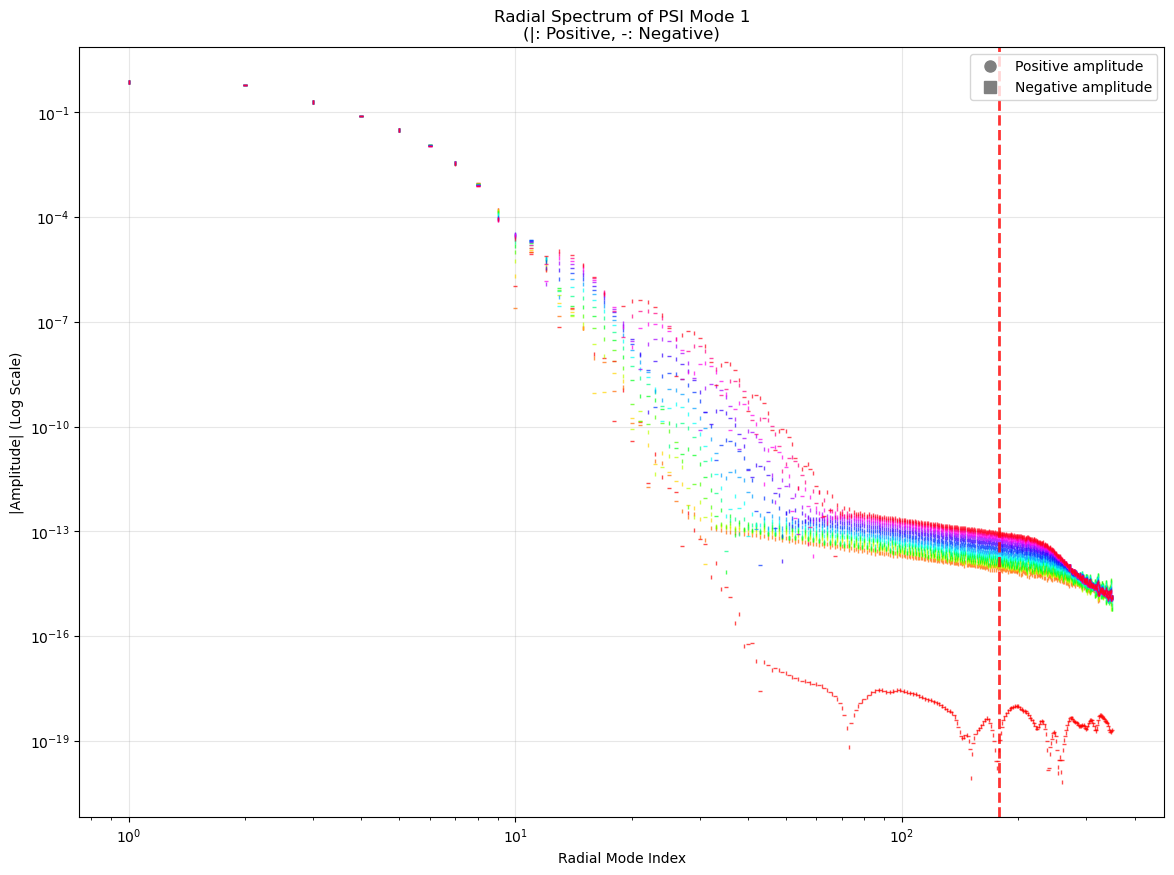

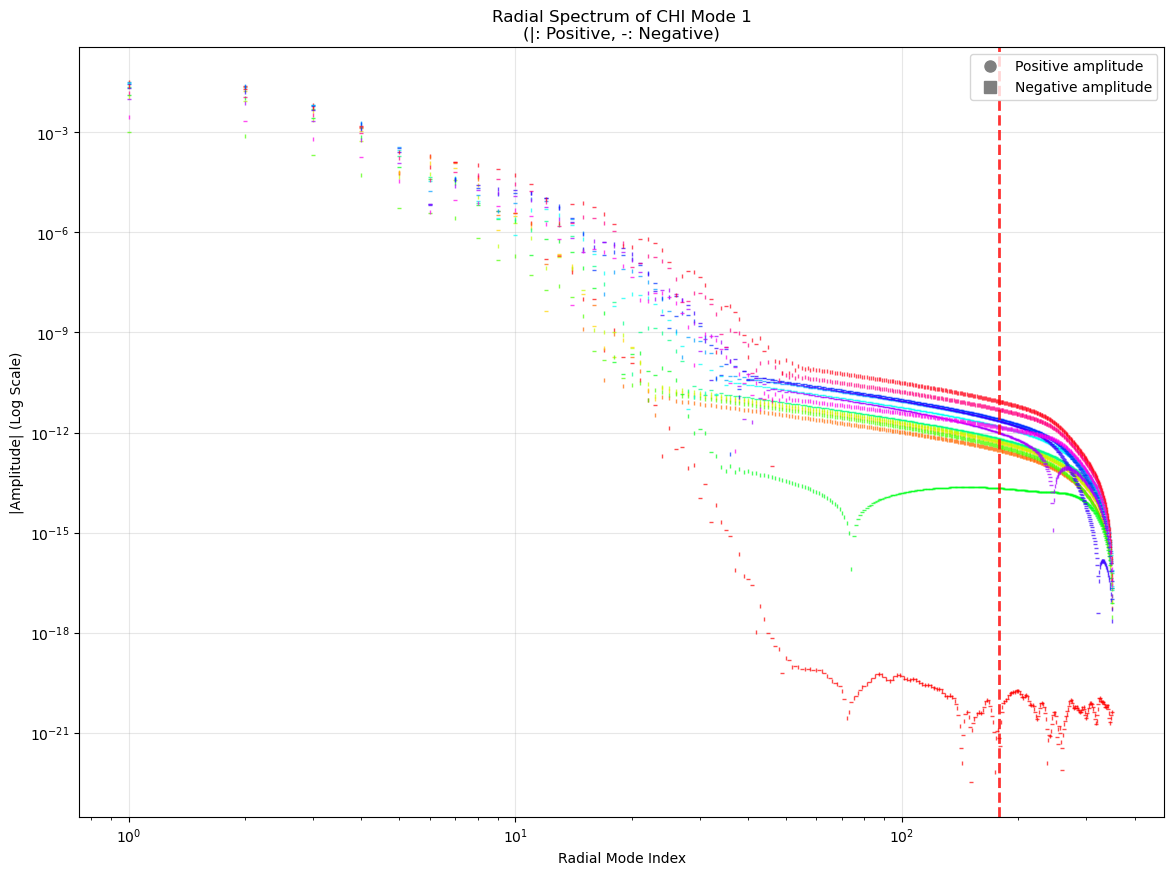

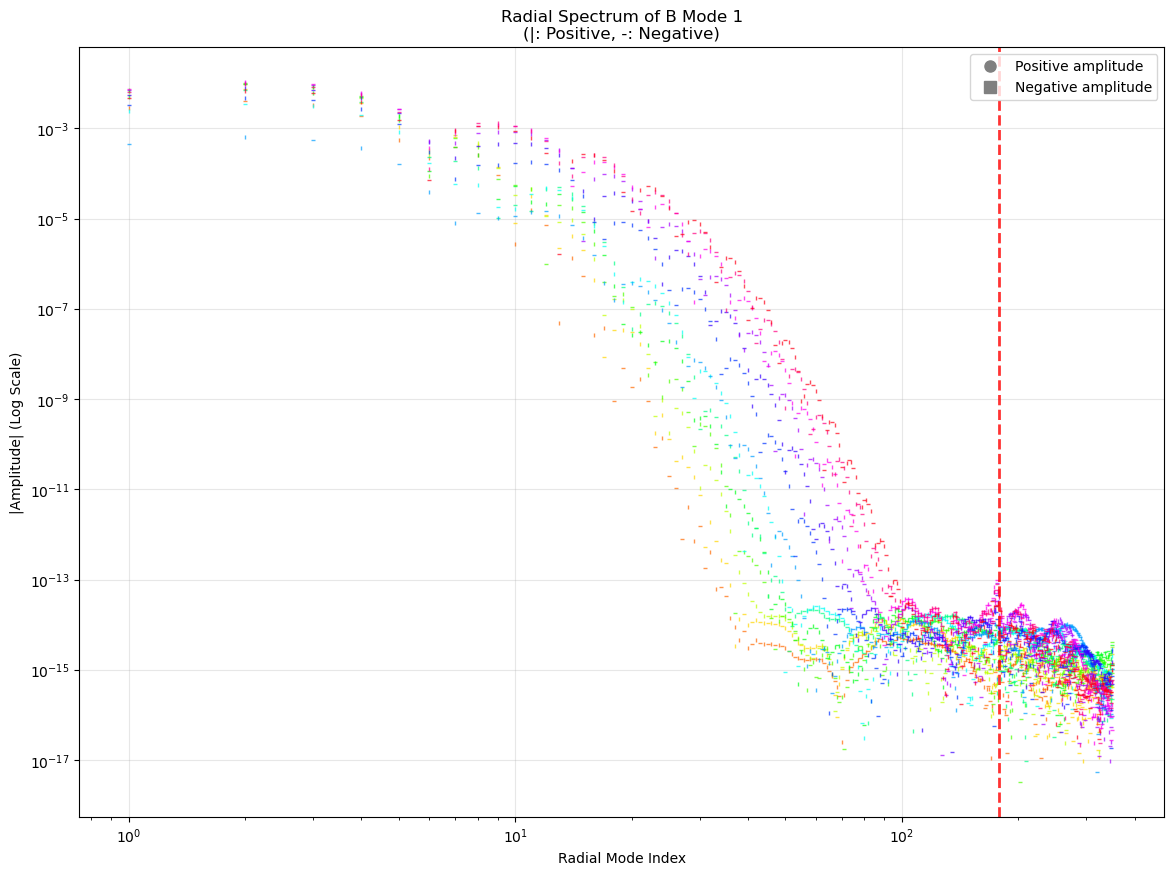

In [50]:
# Read data (automatically handles psi, chi, b)
times, all_data = read_inspect_b_data('../../output/inspect.output')

# # Plot specific variables
# plot_data(times, all_data, variable='psi')   # Plot psi
# plot_data(times, all_data, variable='chi')   # Plot chi  
# plot_data(times, all_data, variable='b')     # Plot b

# Plot spectrum for specific variables
# time_to_plot = list(range(0, int(len(times)),20))
time_to_plot = list(range(0, int(len(times)), 200))
##  time_to_plot = list(range(len(times)-10, len(times)))# 
# time_to_plot = list(range(200, 250))
plot_spectrum(times, all_data, variable='psi', time_indices=time_to_plot)
plot_spectrum(times, all_data, variable='chi', time_indices=time_to_plot)
plot_spectrum(times, all_data, variable='b', time_indices=time_to_plot)

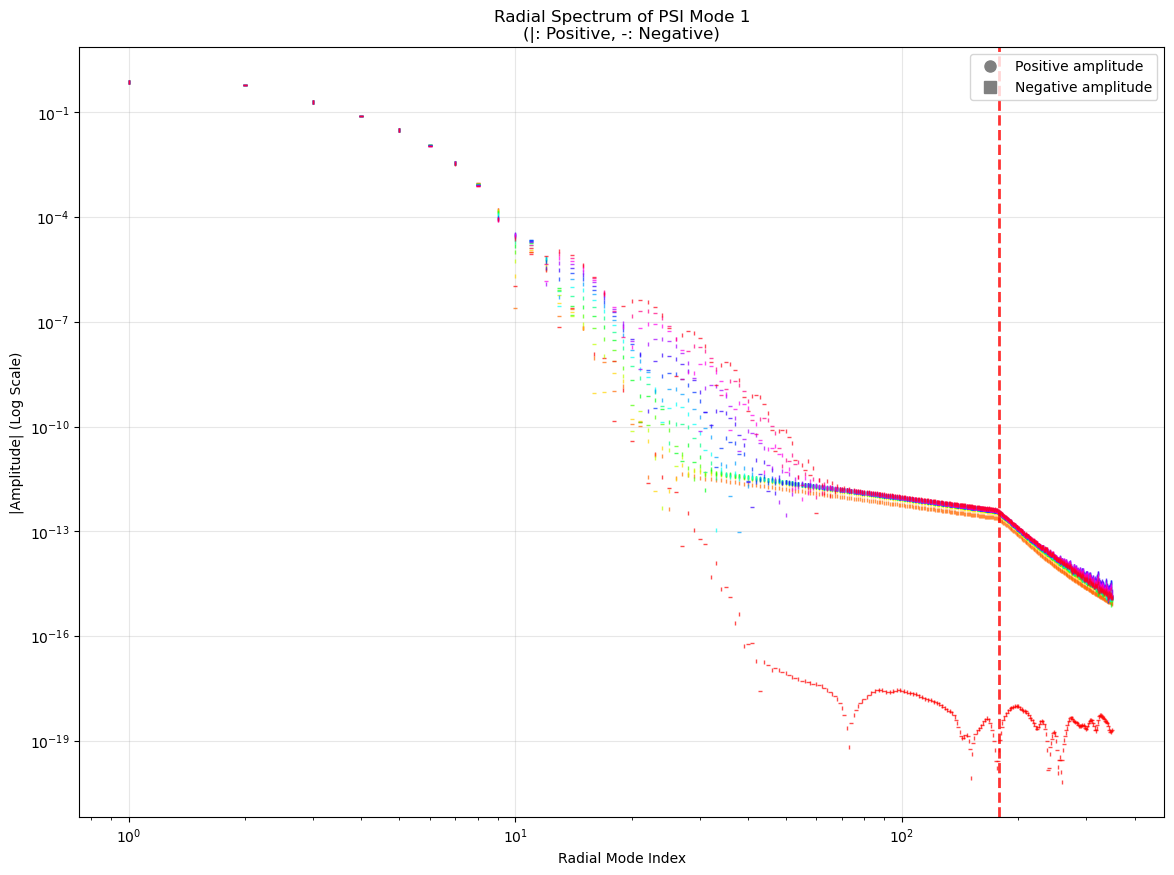

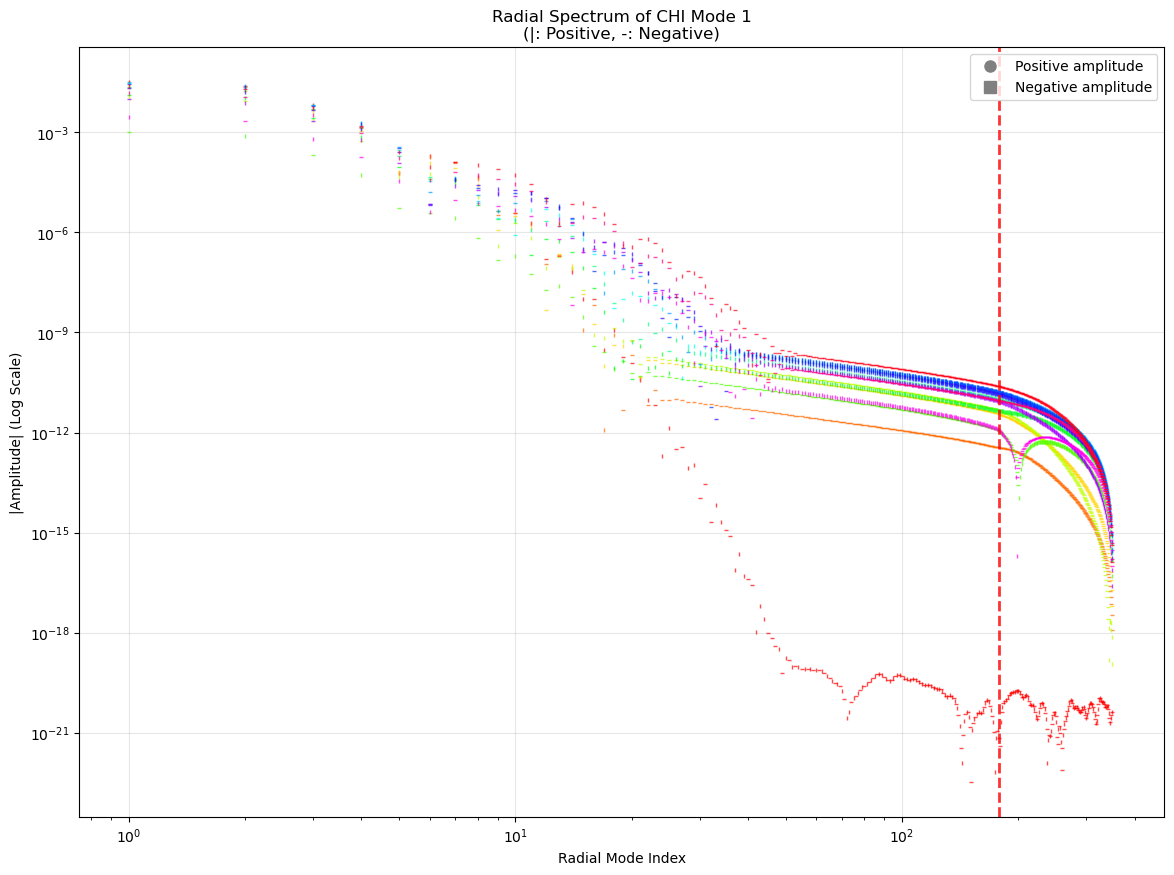

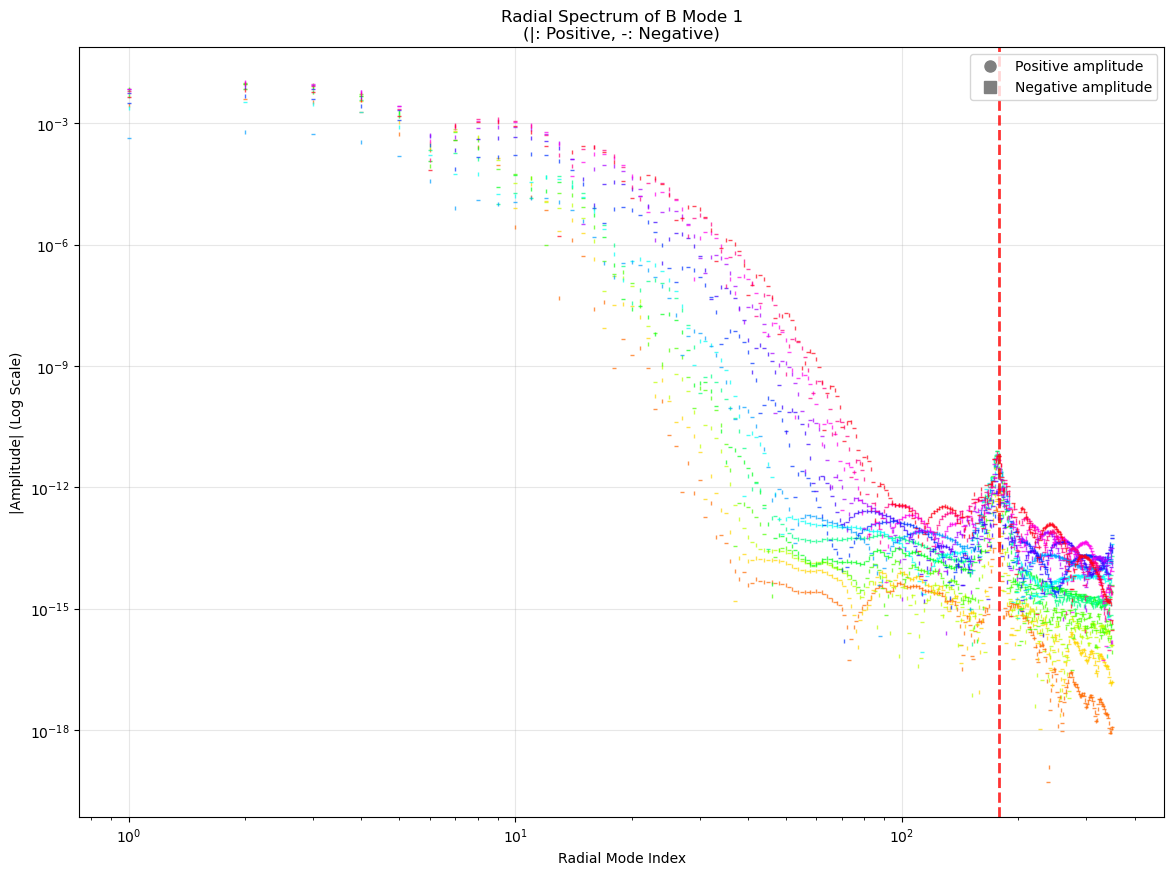

In [51]:
# %%script false --no-raise-error

# Read data (automatically handles psi, chi, b)
times, all_data = read_inspect_b_data('../../output/etd_long_hypv/inspect.output')

# # Plot specific variables
# plot_data(times, all_data, variable='psi')   # Plot psi
# plot_data(times, all_data, variable='chi')   # Plot chi  
# plot_data(times, all_data, variable='b')     # Plot b

# Plot spectrum for specific variables
time_to_plot = list(range(0, int(len(times)), 200))
# time_to_plot = list(range(len(times)-10, len(times)))
# time_to_plot = list(range(0, 50))
plot_spectrum(times, all_data, variable='psi', time_indices=time_to_plot)
plot_spectrum(times, all_data, variable='chi', time_indices=time_to_plot)
plot_spectrum(times, all_data, variable='b', time_indices=time_to_plot)

In [52]:
# Check data structure size - should show data for psi variable
print("First time step psi data shape:", np.shape(all_data[0]['psi']['data']))
print("First time step psi mode:", all_data[0]['psi']['mode_indices'])
print("Number of radial points:", all_data[0]['nrad'])

First time step psi data shape: (1, 356)
First time step psi mode: [1]
Number of radial points: 356


Total adjustment time steps: 29
Time range: 0.002 to 5.600

Data shape summary:
  Hyperviscosity R: (29, 350)
  Hyperdiffusivity R: (29, 350)
  Hyperviscosity T: (29, 136)
  Hyperdiffusivity T: (29, 136)
  Hyperviscosity X: (29, 176)
  Hyperdiffusivity X: (29, 176)

Coefficient ranges:
  Hyperviscosity R: 1.65e-09 to 2.83e-08
  Hyperviscosity T: 1.65e-09 to 1.71e-06
  Hyperviscosity X: 1.65e-09 to 1.00e-08
  Hyperdiffusivity R: 1.71e-09 to 1.98e-08
  Hyperdiffusivity T: 1.65e-09 to 2.06e-08
  Hyperdiffusivity X: 4.19e-09 to 1.30e-08


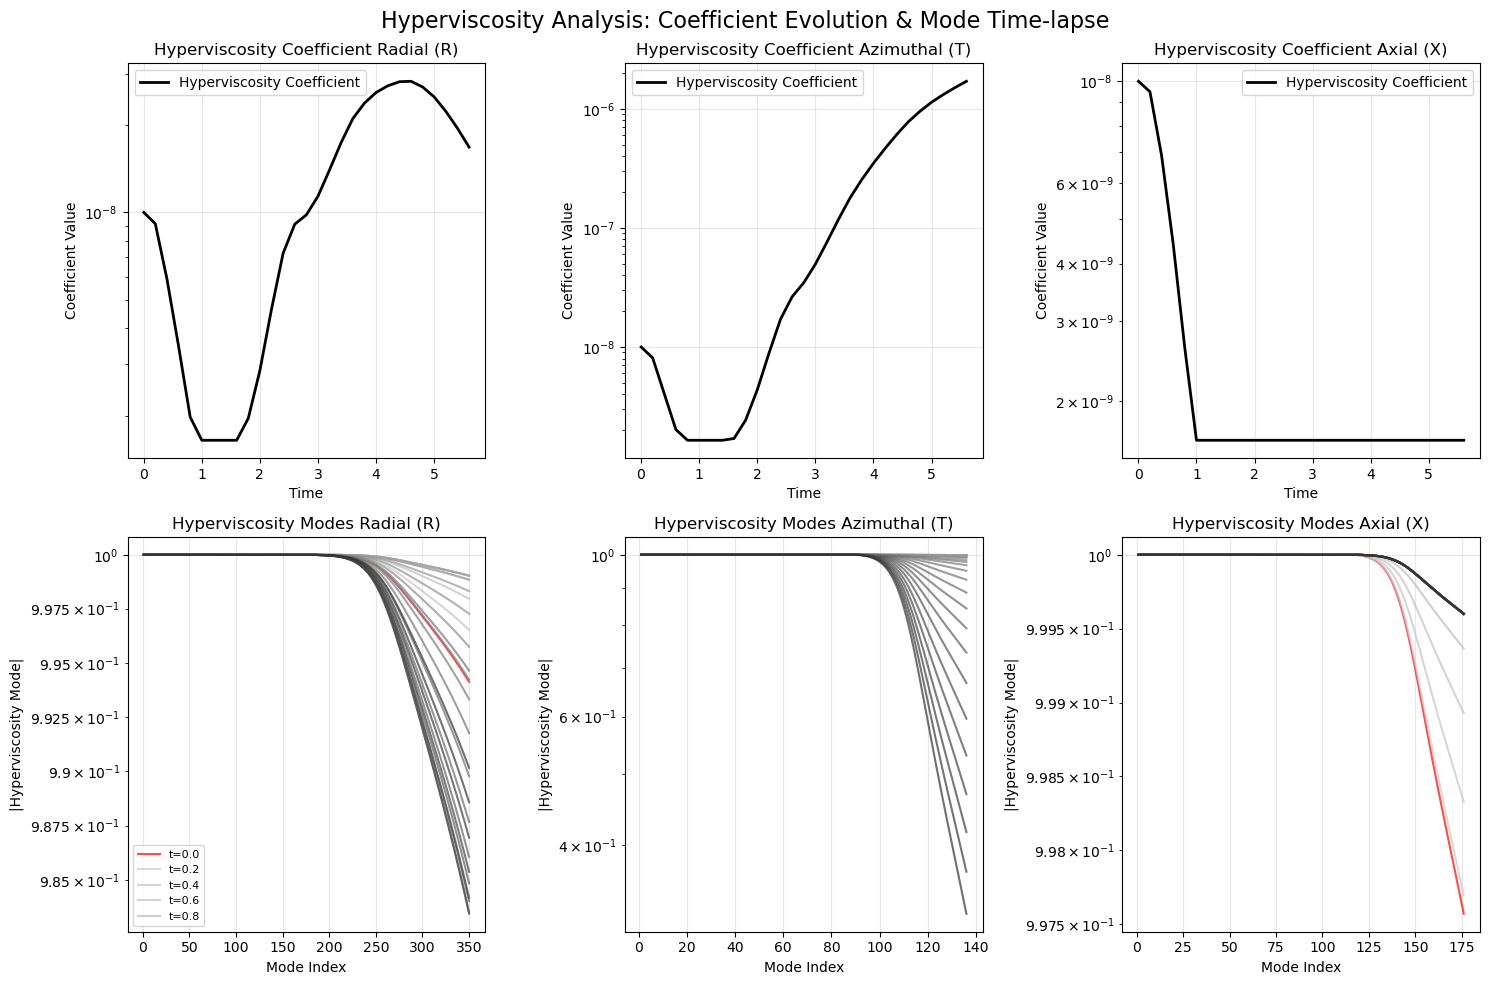

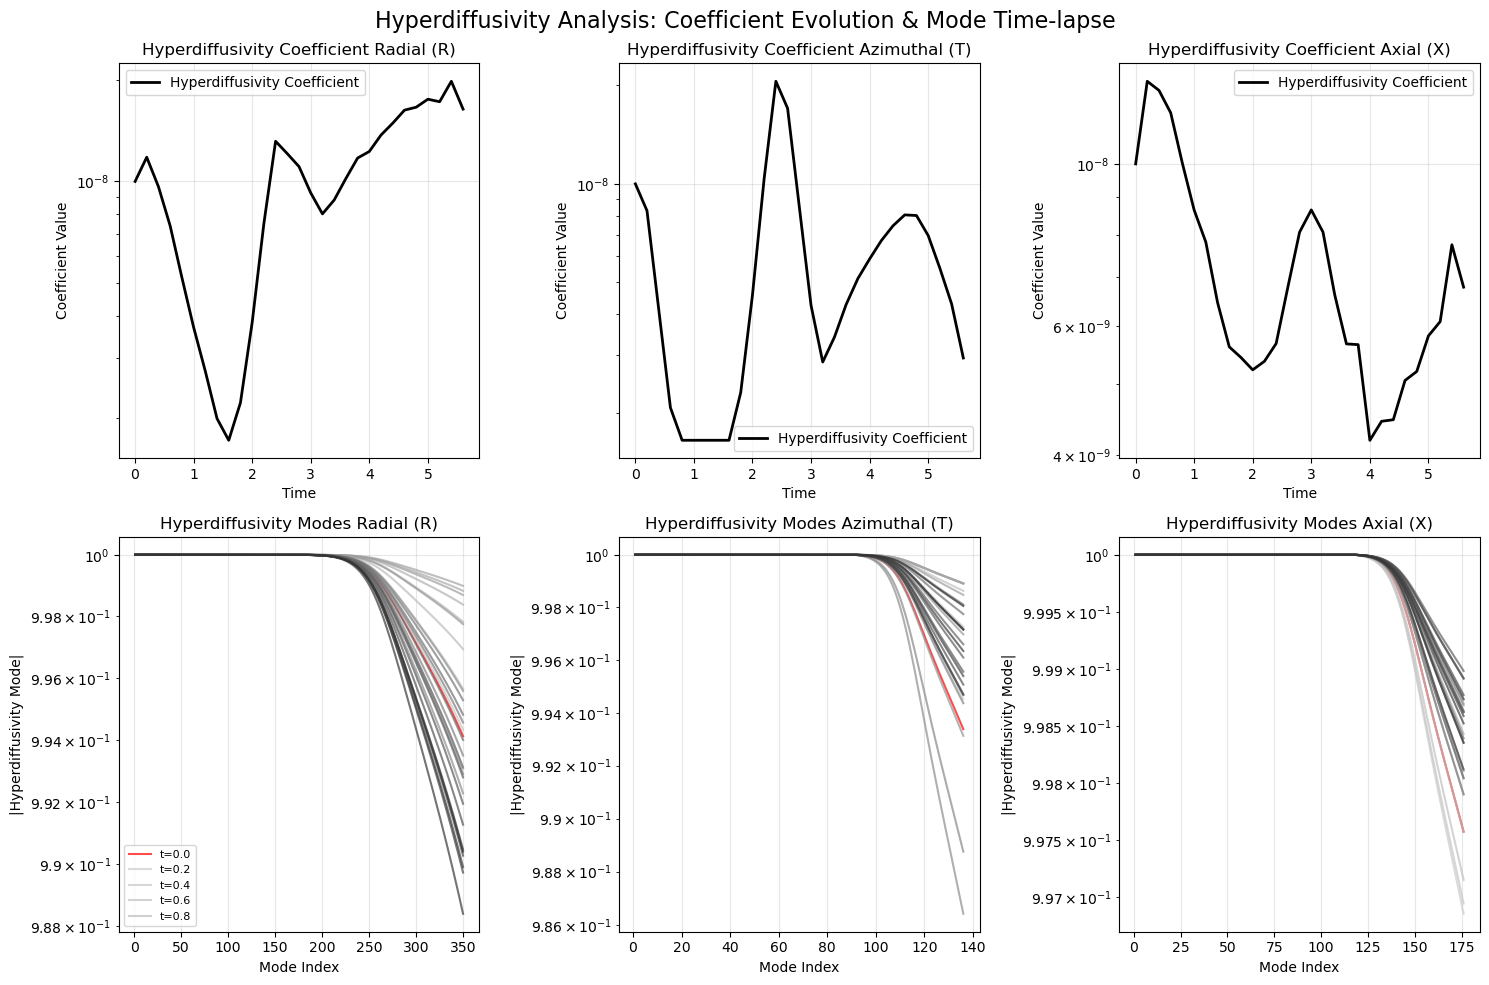

In [53]:
# Read and analyze hyperviscosity data
try:
    times_hv, hyperv_data, kappa_data, nu_values = read_hyperv_data('../../output/hyperv.dat')
    
    # Print summary
    print_hyperv_summary(times_hv, hyperv_data, kappa_data, nu_values)
    
    # Select time indices for plotting (every 10th time step or so)
    time_indices = list(range(0, len(times_hv), max(1, len(times_hv)//15)))
    
    # Plot comprehensive analysis for hyperviscosity (velocity)
    plot_hyperv_complete(times_hv, hyperv_data, kappa_data, nu_values, 
                        data_type='hyperv', time_indices=time_indices)
    
    # Plot comprehensive analysis for hyperdiffusivity (density)
    plot_hyperv_complete(times_hv, hyperv_data, kappa_data, nu_values, 
                        data_type='kappa', time_indices=time_indices)
    
except FileNotFoundError:
    print("hyperv.dat file not found. Make sure the simulation has run with hyperviscosity adjustment.")
except Exception as e:
    print(f"Error reading hyperviscosity data: {e}")